# Install any and all missing requirements (version numbers may vary we will have to check)

In [12]:
from torch.utils.data import dataset
import scipy.io as scio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math
from sklearn.metrics import mean_squared_error
import h5py
import os
import torch
import numpy.fft as fft
import nmrglue as ng
import nmrdenoise
from nmrglue.fileio.bruker import scale_pdata

# Get newest version of nmrdenoise via pip (this is actively updating hence we must run this on jupiter or your terminal)

# Load in the required data files

In [13]:
#if not available download from here https://github.com/rschurko/DESPERATE/blob/master/simulations/Sn_CPMG_id.fid
Sn_CPMG_id = '../global_test_data/Sn_CPMG_id.fid'
bruker_dir_2 = "../global_test_data/ML_2024_sept2_Cholicacid/2/"
bruker_dir_24 = "../global_test_data/ML_2024_sept2_Cholicacid/24/"
model_dir_ld_net = r"../global_test_data/3layerLD.pth"


# Initial view of the data

Optimization terminated successfully.
         Current function value: 867.548149
         Iterations: 127
         Function evaluations: 241


c:\Users\sb3ri\Desktop\nmr_denoising_benchmarks\.venv\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Amplitude')

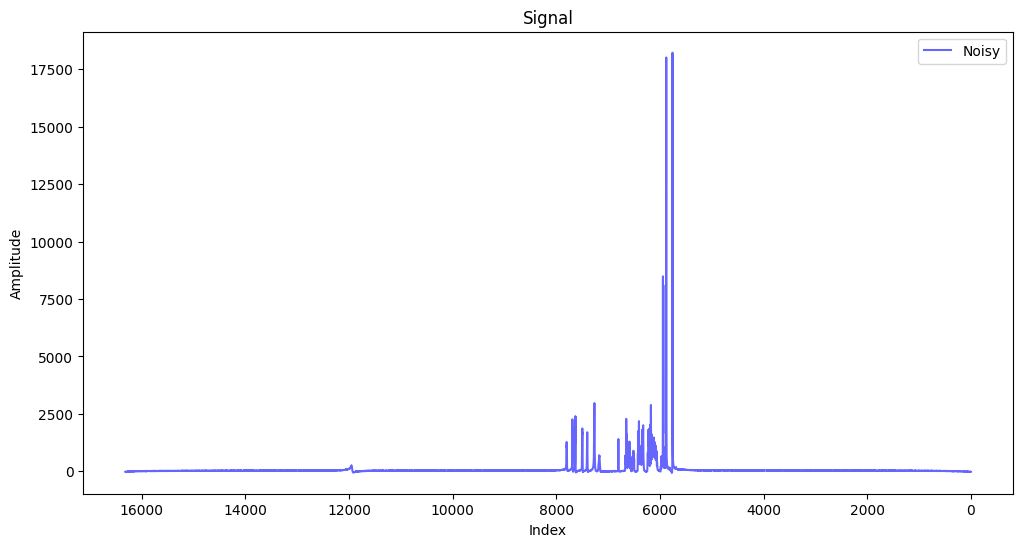

In [14]:

dic, fid = ng.bruker.read(bruker_dir_2)
fid = ng.bruker.remove_digital_filter(dic, fid)
data_high_samp = ng.process.proc_base.fft(fid)
data_high_samp = ng.process.proc_autophase.autops(data_high_samp, 'acme')  # 'acme' for auto phasing
data_high_samp = scale_pdata(dic, data_high_samp) * 2

T = np.size(data_high_samp)  # total duration in seconds
time = np.linspace(0, T, num=np.size(data_high_samp))

plt.figure(figsize=(12, 6))
plt.plot(data_high_samp, label='Noisy', color='blue', alpha=0.6)
plt.gca().invert_xaxis()
plt.legend()
plt.title('Signal')
plt.xlabel('Index')
plt.ylabel('Amplitude')

In [15]:


dic, fid = ng.bruker.read(bruker_dir_24)
fid = ng.bruker.remove_digital_filter(dic, fid)
data = ng.process.proc_base.fft(fid) 
data = ng.process.proc_autophase.autops(data, 'acme')  # auto phasing
data = scale_pdata(dic, data) * 2

fid = ng.bruker.remove_digital_filter(dic, fid)
ideal = ng.process.proc_base.fft(fid)
ideal = ng.process.proc_autophase.autops(ideal, 'acme')  
ideal = scale_pdata(dic, ideal) * 2

real_data = np.real(data)
imag_data = np.imag(data)
max_data = np.max(real_data)
min_data = np.min(real_data)


Optimization terminated successfully.
         Current function value: 22702.569716
         Iterations: 138
         Function evaluations: 254
Optimization terminated successfully.
         Current function value: 32048.526483
         Iterations: 121
         Function evaluations: 228


# Normalize and get data to a viable shape

In [16]:
# crop to multiple of 128 (some of these models are not flexible and sizes T-T)
cropped_data = real_data[:16256]
data_min = cropped_data.min()
data_max = cropped_data.max()
normalized_data = (cropped_data - data_min) / (data_max - data_min)

# Call Desperate

In [17]:
import nmrdenoise as nd

dn = nd.Desperate()
print(nd.__version__)

specrecon, coeffin, coeffs = dn.wavelet_denoise(7, cropped_data, 0, wave = 'bior2.2', threshold = 'mod', alpha = 0)


0.3.5


# Call AE denoise

In [18]:
ae = nd.AE_denoise()
autoencoder_path = ae.load_denoising_checkpoint(model_name="autoencoder_20000_bruker_ver_135_percent_noise_with_noshuffle_v4_rm_spikelets_with_lb_5.pt")
ae_denoised_data, confidence = ae.denoise_component(cropped_data, autoencoder_path)

Loading checkpoint from: c:\Users\sb3ri\Desktop\nmr_denoising_benchmarks\.venv\Lib\site-packages\nmrdenoise\checkpoints\autoencoder_20000_bruker_ver_135_percent_noise_with_noshuffle_v4_rm_spikelets_with_lb_5.pt


Autoencoder model loaded successfully.


# Call LD net

In [ ]:
#shape data to be used in LD net
cropped_data_2 = normalized_data.squeeze()[::]  
fn= len(cropped_data_2)
cropped_data_reform = cropped_data_2.reshape(1, fn)

In [ ]:
# LD net requires us to perform the normalization step wheras the pevious algorithms have this in-built

ld_system = nd.LD_net()
output_ld = ld_system.test(model_dir_ld_net, cropped_data_reform, fn)

# plt.figure(1), plt.plot(np.squeeze(cropped_data_reform))
# plt.figure(2), plt.plot(output)

ImportError: cannot import name 'mock_transwave_submodule' from 'nmrdenoise.core' (c:\Users\sb3ri\Desktop\nmr_denoising_benchmarks\.venv\Lib\site-packages\nmrdenoise\core.py)

# create comparitive plots

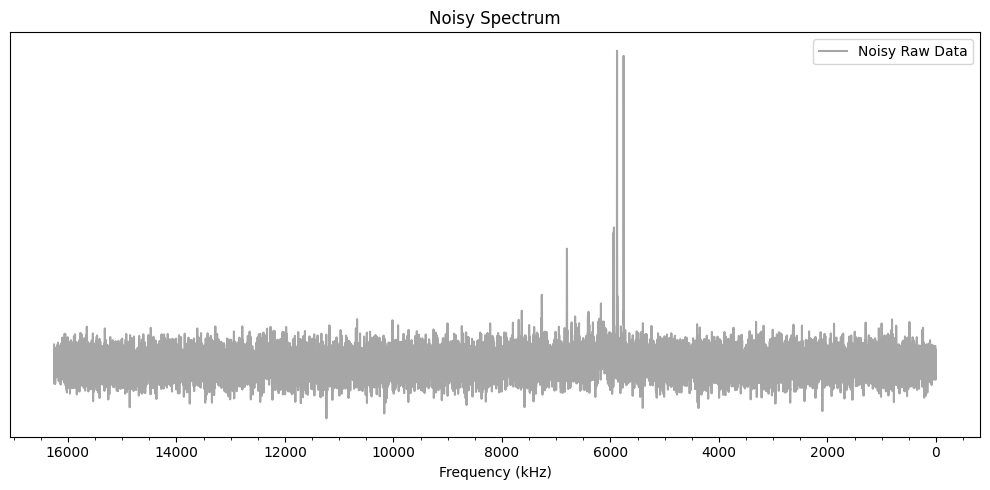

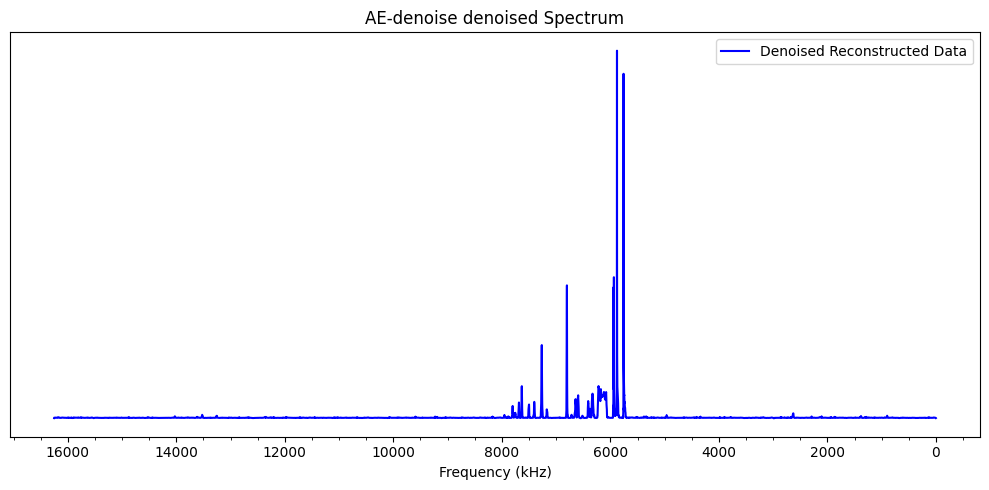

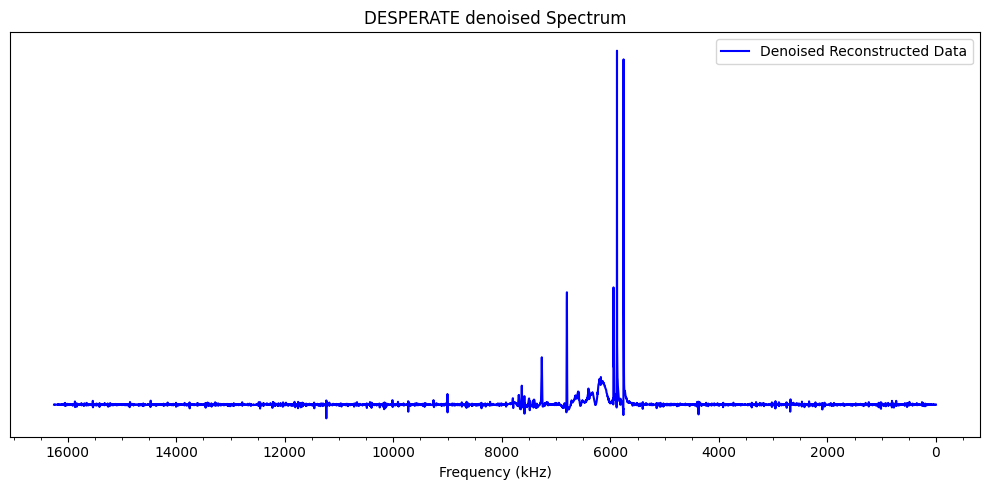

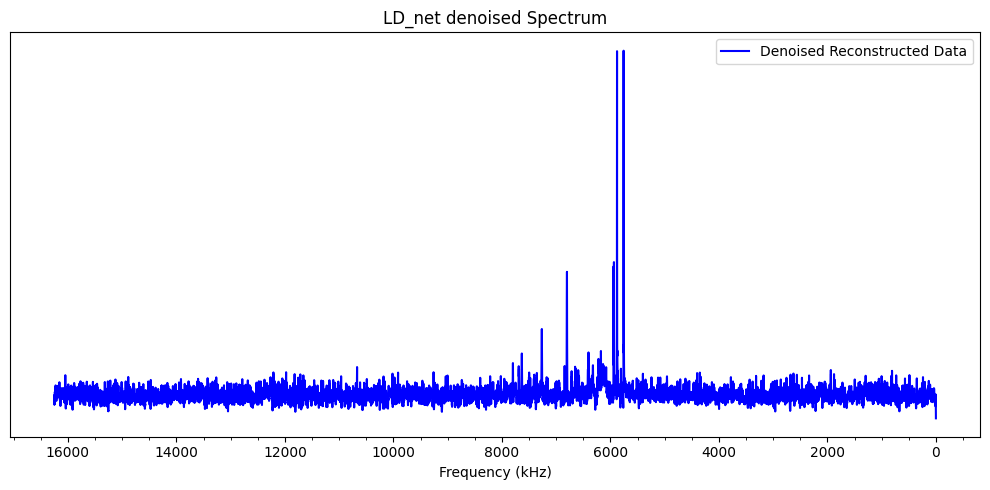

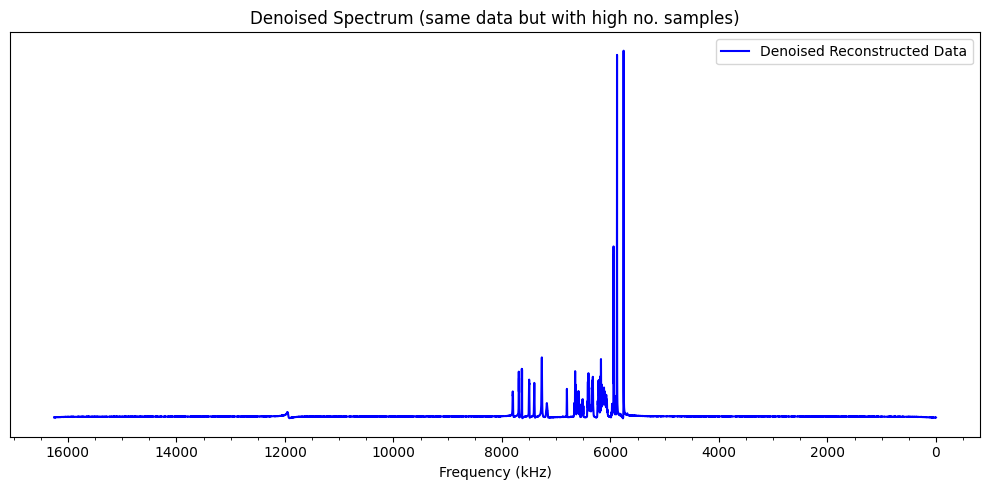

In [ ]:

plt.figure(1, figsize=(10, 5))
plt.plot(cropped_data, color='gray', alpha=0.7, label='Noisy Raw Data')
plt.title('Noisy Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.gca().invert_xaxis()
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()

plt.figure(2, figsize=(10, 5))
plt.plot(ae_denoised_data, color='blue', label='Denoised Reconstructed Data')
plt.title('AE-denoise denoised Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.gca().invert_xaxis()
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()


plt.figure(3, figsize=(10, 5))
plt.plot(specrecon[:-2], color='blue', label='Denoised Reconstructed Data')
plt.title('DESPERATE denoised Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.gca().invert_xaxis()
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()


plt.figure(4, figsize=(10, 5))
plt.plot(output_ld[:16256], color='blue', label='Denoised Reconstructed Data')
plt.title('LD_net denoised Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.gca().invert_xaxis()
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()

plt.figure(5, figsize=(10, 5))
plt.plot(data_high_samp[:16256], color='blue', label='Denoised Reconstructed Data')
plt.title('Denoised Spectrum (same data but with high no. samples)')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.gca().invert_xaxis()
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()


plt.show()
